# 05｜Sequence-Aware Phase-I SPC Process Monitoring

## 專案名稱
**半導體蝕刻製程智慧分析與虛擬量測**  
Semiconductor Etch Process Intelligence & Virtual Metrology

---

## 這份 Notebook 要做什麼？

前面兩份結果已經很清楚：

- 03：多個 Process Signals 會隨 Lot 內的 Wafer Sequence 改變。
- 04：如果忽略這個 sequence structure，Process–Quality relationship 可能被放大、縮小，甚至反轉方向。

所以到 05，我也不能直接把 96 片 wafer 的 raw process means 當成完全 stationary 的資料去畫普通 control chart。

這一份改成先做：

> **每個 Lot 內先扣掉簡單的 linear wafer-sequence trend，再看 residual level 和相鄰 wafer 的 residual change 有沒有特別大的情況。**

主要會回答：

1. 27 個 Main-Process Mean Signals 中，哪些可以建立 residual-based I-MR screening？
2. 哪些 Feature–Wafer residual 超過目前的 provisional I limits？
3. 哪些相鄰 Wafer residual change 超過 provisional MR limits？
4. Main Active Duration 有沒有出現值得回看的 timing signal？
5. 哪些 wafers 同時累積比較多 I / MR evidence，適合交給後面的 multivariate / anomaly analysis？

這裡做的是 **Phase-I retrospective exploratory screening**。

也就是說，它是用目前這批歷史資料找值得回看的 pattern，不是量產 control plan，也不能直接把 flag 當成正式 OOC 判定。


## 1. 載入套件與 03 的 Process 輸入

05 不再讀 Raw NetCDF，而是直接使用 03 已經整理好的：

- `process_wafer_summary.csv`
- `process_sequence_summary.csv`

原因是 Main Active Window 已經在 03 定義和檢查完成，05 不需要再切第二次。

另外，05 做的是 Process Monitoring，所以會使用完整 **96 片 Process Wafers**，不要求一定要有 Quality label。


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 220)

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

process_summary_path = (
    PROCESSED_DATA_DIR / "process_wafer_summary.csv"
)

process_sequence_path = (
    PROCESSED_DATA_DIR / "process_sequence_summary.csv"
)

required_paths = [
    process_summary_path,
    process_sequence_path,
]

missing_paths = [
    path for path in required_paths
    if not path.exists()
]

assert not missing_paths, (
    "缺少必要 03 artifacts："
    + ", ".join(str(path) for path in missing_paths)
)

print("套件與路徑設定完成")
print("Process Summary：", process_summary_path)
print("Process Sequence Summary：", process_sequence_path)

套件與路徑設定完成
Process Summary： C:\Users\momo8\Desktop\semiconductor-etch-process-intelligence\data\processed\process_wafer_summary.csv
Process Sequence Summary： C:\Users\momo8\Desktop\semiconductor-etch-process-intelligence\data\processed\process_sequence_summary.csv


### 這個輸出代表什麼？

兩份 03 的 Process artifacts 都能正常找到。

所以 05 後面直接沿用：

- wafer identity
- Main Active Window
- 27 個 Main-Process Mean Features

換句話說，05 和 03 的差別只在分析方法，不在資料切法。

這樣做可以避免一個很實際的問題：如果 05 自己又重切一次 Process Window，後面看到的 SPC flag 有可能只是 segmentation 不一致造成，而不是真正的 process variation。


## 2. 載入後先確認 03 的 Process 資料沒有改掉

05 進來時要確認：

- Process Wafers = 96
- Lots = 10
- Lot 7 = 6 片，其餘 Lots = 10 片
- `main_mean__*` features = 27
- terminal-gap wafers = 69
- Main Active Duration 約 591.8–602.2 秒

同時也會讀 03 的 process-sequence summary，確認前面看到的 sequence pattern 仍然是同一份資料。


In [2]:
process_wafer_summary = pd.read_csv(
    process_summary_path
)

process_sequence_summary = pd.read_csv(
    process_sequence_path
)

required_columns = {
    "experiment_key",
    "lot_number",
    "wafer_number",
    "terminal_gap",
    "main_active_duration",
}

missing_columns = (
    required_columns
    - set(process_wafer_summary.columns)
)

assert not missing_columns, (
    f"process_wafer_summary 缺少欄位：{sorted(missing_columns)}"
)

main_mean_columns = [
    column
    for column in process_wafer_summary.columns
    if column.startswith("main_mean__")
]

usable_process_features = [
    column.replace("main_mean__", "")
    for column in main_mean_columns
]

assert len(process_wafer_summary) == 96
assert process_wafer_summary["experiment_key"].is_unique
assert process_wafer_summary["lot_number"].nunique() == 10
assert len(main_mean_columns) == 27
assert int(process_wafer_summary["terminal_gap"].sum()) == 69
assert len(process_sequence_summary) == 27

wafers_by_lot = (
    process_wafer_summary
    .groupby("lot_number")
    .size()
    .rename("n_wafers")
    .reset_index()
)

duration_summary = (
    process_wafer_summary[
        "main_active_duration"
    ]
    .describe()
)

print("Process Wafers：", len(process_wafer_summary))
print("Lots：", process_wafer_summary["lot_number"].nunique())
print("Main Mean Features：", len(main_mean_columns))
print(
    "Terminal Gap Wafers：",
    int(process_wafer_summary["terminal_gap"].sum()),
)

display(wafers_by_lot)
display(duration_summary)

Process Wafers： 96
Lots： 10
Main Mean Features： 27
Terminal Gap Wafers： 69


,lot_number,n_wafers
0,1,10
1,2,10
2,3,10
3,4,10
4,5,10
5,6,10
6,7,6
7,8,10
8,9,10
9,10,10


count     96.000000
mean     597.542083
std        2.198244
min      591.800000
25%      597.100000
50%      598.000000
75%      598.000000
max      602.200000
Name: main_active_duration, dtype: float64

### 這個結果實際告訴我們什麼？

05 使用的是完整 **96 片 Process Wafers**，不是 04 做 Process–Quality relationship 時的 88 片 matched wafers。

這表示那 **8 片沒有 Quality label 的 wafers** 在這裡仍然會保留，因為 Process Monitoring 本身不需要 metrology outcome。

Main Active Duration 的結果是：

- Mean ≈ **597.54 秒**
- Std ≈ **2.20 秒**

Std 大約只有平均值的 **0.37%**，所以主要高功率製程區段的時間長度整體很穩定。

另外，69 片 terminal-gap wafers 只是 01 / 03 已經辨識過的時間軸結尾現象。03 建 Main Active Window 時已經處理過，所以這裡不能把「69」解讀成 69 片製程異常。


# Part A｜Lot-Specific Sequence Residuals

## 3. 先把每個 Feature 在各 Lot 的 Linear Sequence Trend 扣掉

對每個 Process Feature、每個 Lot，我會先建立：

`Process Main Mean = a + b × Wafer Number + residual`

其中 `residual` 可以理解成：

> 這片 wafer 的 Process Mean，和該 Lot 依 wafer sequence 預期值之間差多少。

如果某個 feature 在某個 Lot 幾乎完全不變，就會標記：

- `valid_lot = False`
- residual 設成 0
- 不拿這個 Lot 來估計該 feature 的 SPC scale

這樣可以避免本來幾乎沒有變化的 signal，只因為 floating-point noise 就被當成真實製程波動。


In [3]:
residual_records = []

for feature in usable_process_features:
    mean_column = f"main_mean__{feature}"

    for lot_number, group in (
        process_wafer_summary
        .groupby("lot_number")
    ):
        group = group.sort_values("wafer_number")

        x = group[
            "wafer_number"
        ].to_numpy(dtype=float)

        y = group[
            mean_column
        ].to_numpy(dtype=float)

        is_flat = np.allclose(
            y,
            y[0],
            rtol=1e-7,
            atol=1e-8,
        )

        if is_flat:
            predicted = np.full_like(
                y,
                np.mean(y),
            )
            residuals = np.zeros_like(y)
            valid_lot = False
            slope = 0.0
        else:
            slope, intercept = np.polyfit(
                x,
                y,
                deg=1,
            )
            predicted = intercept + slope * x
            residuals = y - predicted
            valid_lot = True

        for (
            experiment_key,
            wafer_number,
            process_mean,
            expected,
            residual,
        ) in zip(
            group["experiment_key"],
            group["wafer_number"],
            y,
            predicted,
            residuals,
        ):
            residual_records.append(
                {
                    "feature": feature,
                    "experiment_key": experiment_key,
                    "lot_number": int(lot_number),
                    "wafer_number": int(wafer_number),
                    "process_mean": float(process_mean),
                    "expected_from_sequence": float(expected),
                    "residual": float(residual),
                    "sequence_slope": float(slope),
                    "valid_lot": bool(valid_lot),
                }
            )

spc_residuals = pd.DataFrame(residual_records)

assert len(spc_residuals) == (
    len(usable_process_features)
    * len(process_wafer_summary)
)

print("Residual Records：", len(spc_residuals))
print(
    "Expected：",
    len(usable_process_features)
    * len(process_wafer_summary),
)

spc_residuals.head()

Residual Records： 2592
Expected： 2592


,feature,experiment_key,lot_number,wafer_number,process_mean,expected_from_sequence,residual,sequence_slope,valid_lot
0,Stat3_Etch_MV_EpdIntensity,2024-07-02_01,1,1,0.123,0.123,0.0,0.0,False
1,Stat3_Etch_MV_EpdIntensity,2024-07-02_02,1,2,0.123,0.123,0.0,0.0,False
2,Stat3_Etch_MV_EpdIntensity,2024-07-02_03,1,3,0.123,0.123,0.0,0.0,False
3,Stat3_Etch_MV_EpdIntensity,2024-07-02_04,1,4,0.123,0.123,0.0,0.0,False
4,Stat3_Etch_MV_EpdIntensity,2024-07-02_05,1,5,0.123,0.123,0.0,0.0,False


### 這個結果實際告訴我們什麼？

一共建立 **2,592 筆 residual records**。

這剛好等於：

**27 features × 96 wafers = 2,592**

所以每一個 Feature × Wafer 都有一個對應的 sequence-adjusted residual。

Residual 的方向可以直接這樣看：

- residual > 0：這片 wafer 的 Process Mean 高於該 Lot linear trend 預期
- residual < 0：低於預期
- residual ≈ 0：接近該 Lot 的 sequence trend

因為 03 已經確認很多 process signals 會跟著 wafer number 變，所以 05 監控 residual 比直接監控 raw mean 更合理。

另外，`valid_lot=False` 不是異常。它只是表示某個 feature 在那個 Lot 幾乎沒有 variation，沒有足夠 residual variability 可以拿來估計 control scale。


# Part B｜Provisional Residual I-MR Limits

## 4. 用 Sequence-Adjusted Residual 建立 I-MR Screening Limits

Moving Range size = 2，所以使用：

- `d2 = 1.128`
- `D4 = 3.267`

先在每個 Lot 內照 Wafer Number 計算：

`MR = |residual_current - residual_previous|`

這裡**不跨 Lot**，因為 Lot 1 的最後一片和 Lot 2 的第一片不是同一段連續 wafer sequence。

接著對同一 feature 的有效 Lots 合併 MR values，估計：

`Sigma_hat = MR_bar / d2`

再建立：

### I Chart
`Center ± 3 × Sigma_hat`

### MR Chart
`UCL_MR = D4 × MR_bar`

這裡的 limits 只能叫 provisional screening limits，原因是：

- sequence trend 和 residual 都是用同一批 Phase-I data fit 出來的
- residual 不是原始獨立 observation
- 合併不同 Lots 時，等於假設 residual scale 大致可比較
- 一次同時看很多 features，本來就可能自然產生一些 flags

所以後面的 flag 只代表「值得回看」，不是正式 production OOC。


In [4]:
D2 = 1.128
D4 = 3.267

spc_feature_records = []
mr_records = []

for feature in usable_process_features:
    feature_df = (
        spc_residuals.loc[
            (
                spc_residuals["feature"] == feature
            )
            &
            (
                spc_residuals["valid_lot"]
            )
        ]
        .copy()
    )

    valid_lots = int(
        feature_df["lot_number"].nunique()
    )

    n_valid_wafers = len(feature_df)

    moving_ranges = []

    for lot_number, group in (
        feature_df
        .groupby("lot_number")
    ):
        group = group.sort_values("wafer_number")

        residual_values = (
            group["residual"]
            .to_numpy(dtype=float)
        )

        if len(residual_values) < 2:
            continue

        lot_mr = np.abs(
            np.diff(residual_values)
        )

        moving_ranges.extend(
            lot_mr.tolist()
        )

        previous_rows = group.iloc[:-1]
        current_rows = group.iloc[1:]

        for (
            previous_key,
            previous_wafer,
            current_key,
            current_wafer,
            mr_value,
        ) in zip(
            previous_rows["experiment_key"],
            previous_rows["wafer_number"],
            current_rows["experiment_key"],
            current_rows["wafer_number"],
            lot_mr,
        ):
            mr_records.append(
                {
                    "feature": feature,
                    "lot_number": int(lot_number),
                    "previous_experiment_key": previous_key,
                    "previous_wafer_number": int(previous_wafer),
                    "experiment_key": current_key,
                    "wafer_number": int(current_wafer),
                    "moving_range": float(mr_value),
                }
            )

    n_valid_mr_pairs = len(moving_ranges)

    if (
        n_valid_wafers >= 2
        and n_valid_mr_pairs > 0
    ):
        center = float(
            feature_df["residual"].mean()
        )

        mr_bar = float(
            np.mean(moving_ranges)
        )

        if mr_bar > 0:
            sigma_mr = mr_bar / D2

            lcl = center - 3 * sigma_mr
            ucl = center + 3 * sigma_mr
            mr_ucl = D4 * mr_bar

            residual_values = (
                feature_df["residual"]
                .to_numpy(dtype=float)
            )

            n_i_violations = int(
                (
                    (residual_values < lcl)
                    |
                    (residual_values > ucl)
                )
                .sum()
            )

            max_abs_z = float(
                np.max(
                    np.abs(
                        (
                            residual_values - center
                        )
                        / sigma_mr
                    )
                )
            )

            n_mr_violations = int(
                (
                    np.asarray(moving_ranges)
                    > mr_ucl
                )
                .sum()
            )
        else:
            sigma_mr = np.nan
            lcl = np.nan
            ucl = np.nan
            mr_ucl = np.nan
            n_i_violations = 0
            max_abs_z = np.nan
            n_mr_violations = 0
    else:
        center = np.nan
        mr_bar = np.nan
        sigma_mr = np.nan
        lcl = np.nan
        ucl = np.nan
        mr_ucl = np.nan
        n_i_violations = 0
        max_abs_z = np.nan
        n_mr_violations = 0

    i_violation_rate_pct = (
        n_i_violations
        / n_valid_wafers
        * 100
        if n_valid_wafers > 0
        else np.nan
    )

    mr_violation_rate_pct = (
        n_mr_violations
        / n_valid_mr_pairs
        * 100
        if n_valid_mr_pairs > 0
        else np.nan
    )

    spc_feature_records.append(
        {
            "feature": feature,
            "valid_lots": valid_lots,
            "n_valid_wafers": int(n_valid_wafers),
            "center": center,
            "sigma_mr": sigma_mr,
            "lcl": lcl,
            "ucl": ucl,
            "n_i_violations": n_i_violations,
            "i_violation_rate_pct": i_violation_rate_pct,
            "max_abs_z": max_abs_z,
            "mr_bar": mr_bar,
            "mr_ucl": mr_ucl,
            "n_valid_mr_pairs": int(n_valid_mr_pairs),
            "n_mr_violations": n_mr_violations,
            "mr_violation_rate_pct": mr_violation_rate_pct,
        }
    )

spc_feature_summary = (
    pd.DataFrame(spc_feature_records)
    .sort_values(
        ["n_i_violations", "max_abs_z"],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)

spc_moving_ranges = pd.DataFrame(
    mr_records
)

assert len(spc_feature_summary) == 27
assert len(spc_moving_ranges) == 2118

print(
    "Feature Summary Rows：",
    len(spc_feature_summary),
)
print(
    "Moving Range Records：",
    len(spc_moving_ranges),
)

display(
    spc_feature_summary[
        [
            "feature",
            "valid_lots",
            "n_valid_wafers",
            "n_i_violations",
            "i_violation_rate_pct",
            "max_abs_z",
            "n_valid_mr_pairs",
            "n_mr_violations",
            "mr_violation_rate_pct",
        ]
    ].head(15)
)

Feature Summary Rows： 27
Moving Range Records： 2118


,feature,valid_lots,n_valid_wafers,n_i_violations,i_violation_rate_pct,max_abs_z,n_valid_mr_pairs,n_mr_violations,mr_violation_rate_pct
0,Stat3_Etch_MV_Gas7Flow,10,96,8,8.333333,5.018226,86,4,4.651163
1,Stat3_Etch_MV_PlatenRFTuningCapacitor,10,96,7,7.291667,3.366538,86,0,0.000000
2,Stat3_Etch_MV_Heater4Temp,10,96,5,5.208333,6.993740,86,2,2.325581
3,Stat3_Etch_MV_Gas1Flow,10,96,5,5.208333,4.366947,86,8,9.302326
4,Stat3_Etch_MV_Heater2Temp,10,96,3,3.125000,4.852115,86,2,2.325581
5,Stat3_Etch_MV_SourceRFLoadPower,10,96,3,3.125000,3.289013,86,5,5.813953
6,Stat3_Etch_MV_SourceRF2TuningCapacitor,6,60,3,5.000000,3.272144,54,4,7.407407
7,Stat3_Etch_MV_Gas2Flow,10,96,2,2.083333,3.706498,86,2,2.325581
8,Stat3_Etch_MV_Heater3Temp,10,96,2,2.083333,3.557716,86,1,1.162791
9,Stat3_Etch_MV_ForeLinePressure,10,96,2,2.083333,3.377450,86,3,3.488372


### 這個結果實際告訴我們什麼？

Feature summary 一共有 **27 rows**，也就是每個 Main-Process Mean Feature 都有一列 SPC summary。

目前最值得注意的是：**I flag 多和 MR flag 多不是同一種製程行為。**

例如：

- `Gas7Flow`：**8 個 I flags、4 個 MR flags**  
  代表既有多片 wafer 的 residual level 偏離 trend，也有一些相鄰 wafer 間的 jump。

- `PlatenRFTuningCapacitor`：**7 個 I flags、0 個 MR flags**  
  比較像某些 wafer 本身的 residual level 偏高或偏低，但相鄰 wafer 之間不常出現突然的大跳動。

- `Gas1Flow`：**5 個 I flags、8 個 MR flags**  
  level deviation 和 adjacent-wafer transition 兩種 evidence 都有。

- `PlatenRFLoadCapacitor`：**2 個 I flags、7 個 MR flags**  
  單片 wafer 不一定常超出 I limit，但相鄰 wafer 的變化幅度比較容易超出自己的 MR limit。

另外，`SourceRF2TuningCapacitor` 只有 **6 個 valid Lots / 60 wafers**，所以它的 violation rate 必須和較少的有效資料量一起看，不能直接和 10 個 valid Lots 的 features 當成完全同等比較。

所以這張表真正要看的，是每個 signal 比較偏向「level deviation」還是「transition jump」，而不是只比誰的 flag 總數最大。


## 5. 整理 I-Chart Flagged Feature–Wafer

I-chart flag 代表：

> 某個 feature 在某片 wafer 的 sequence-adjusted residual level 超過目前 provisional I limits。

這裡要分清楚兩個數字：

- `Flagged Feature-Wafer Rows`：一個 feature 在一片 wafer 上被 flag，就算一筆
- `Unique Flagged Wafers`：至少有一個 I flag 的 wafer 數

同一片 wafer 可能同時有好幾個 features 被 flag，所以兩個數字本來就不會一樣。


In [5]:
limit_lookup = (
    spc_feature_summary
    .set_index("feature")
)

flagged_records = []

for _, row in (
    spc_residuals.loc[
        spc_residuals["valid_lot"]
    ]
    .iterrows()
):
    limits = limit_lookup.loc[row["feature"]]

    if not np.isfinite(limits["sigma_mr"]):
        continue

    is_violation = (
        row["residual"] < limits["lcl"]
        or row["residual"] > limits["ucl"]
    )

    if not is_violation:
        continue

    flagged_records.append(
        {
            "feature": row["feature"],
            "experiment_key": row["experiment_key"],
            "lot_number": int(row["lot_number"]),
            "wafer_number": int(row["wafer_number"]),
            "process_mean": row["process_mean"],
            "expected_from_sequence": row[
                "expected_from_sequence"
            ],
            "residual": row["residual"],
            "sigma_mr": limits["sigma_mr"],
            "standardized_residual": (
                (
                    row["residual"]
                    - limits["center"]
                )
                / limits["sigma_mr"]
            ),
        }
    )

spc_flagged_wafers = pd.DataFrame(
    flagged_records
)

assert len(spc_flagged_wafers) == 46
assert (
    spc_flagged_wafers[
        "experiment_key"
    ].nunique()
    == 19
)

print(
    "Flagged Feature-Wafer Rows：",
    len(spc_flagged_wafers),
)
print(
    "Unique Flagged Wafers：",
    spc_flagged_wafers[
        "experiment_key"
    ].nunique(),
)

display(
    spc_flagged_wafers[
        [
            "feature",
            "experiment_key",
            "lot_number",
            "wafer_number",
            "residual",
            "standardized_residual",
        ]
    ]
    .sort_values(
        "standardized_residual",
        key=lambda s: s.abs(),
        ascending=False,
    )
    .head(20)
)

Flagged Feature-Wafer Rows： 46
Unique Flagged Wafers： 19


,feature,experiment_key,lot_number,wafer_number,residual,standardized_residual
23,Stat3_Etch_MV_Heater4Temp,2024-08-07_08,8,8,0.050041,6.993740
9,Stat3_Etch_MV_Gas7Flow,2024-07-05_01,2,1,-0.104194,-5.018226
19,Stat3_Etch_MV_Heater2Temp,2024-08-07_09,8,9,0.045722,4.852115
25,Stat3_Etch_MV_Heater4Temp,2024-08-07_10,8,10,-0.034311,-4.795336
18,Stat3_Etch_MV_Heater2Temp,2024-08-07_06,8,6,-0.044694,-4.743020
24,Stat3_Etch_MV_Heater4Temp,2024-08-07_09,8,9,0.032833,4.588810
15,Stat3_Etch_MV_Gas7Flow,2024-08-07_08,8,8,-0.092833,-4.471038
5,Stat3_Etch_MV_Gas1Flow,2024-08-07_08,8,8,0.354637,4.366947
4,Stat3_Etch_MV_Gas1Flow,2024-07-19_09,5,9,0.336235,4.140354
14,Stat3_Etch_MV_Gas7Flow,2024-08-07_07,8,7,0.079847,3.845601


### 這個結果實際告訴我們什麼？

目前一共有：

- **46 個 Feature–Wafer I flags**
- 但只落在 **19 片 unique wafers**

也就是說，I flags 不是平均散在很多 wafer 上，而是有明顯聚集。有些 wafer 會同時觸發好幾個 features。

在目前顯示的較極端 residual 中：

- `2024-08-07_08` 的 `Heater4Temp` standardized residual 約 **+6.99**
- `2024-07-05_01` 的 `Gas7Flow` standardized residual 約 **-5.02**

另外，top residual rows 裡有多筆來自 **Lot 8**。

這件事很重要，因為它提醒我不能把每一個 flag 都直接解釋成「某個獨立 sensor 故障」。如果很多 signals 在同一個 Lot、同幾片 wafer 一起偏離，也可能代表：

- Lot 8 有 non-linear sequence pattern
- 有 shared process-state shift
- Lot 8 的 residual variance 和其他 Lots 不一樣
- linear detrending 對這個 Lot 不夠好

所以 standardized residual 在這裡只是用來比較「相對偏離程度」，不能直接當成正式常態分布下的 sigma probability。


## 6. 看有 I Flags 的 Features 和幾張代表性 I Charts

這裡先列出有 I flags 的 features，再畫前 4 個代表性的 residual I charts。

圖上的 Y 軸不是原始 sensor value，而是：

`Actual Main Mean - Expected Main Mean from Lot Sequence Trend`

所以圖上看到的是「扣掉該 Lot 線性 sequence trend 後還剩多少偏離」。

另外，Lot 和 Lot 之間不連線，避免把不同 Lots 誤當成一段連續時間序列。


,feature,valid_lots,n_valid_wafers,n_i_violations,i_violation_rate_pct,max_abs_z,n_valid_mr_pairs,n_mr_violations,mr_violation_rate_pct
0,Stat3_Etch_MV_Gas7Flow,10,96,8,8.333333,5.018226,86,4,4.651163
1,Stat3_Etch_MV_PlatenRFTuningCapacitor,10,96,7,7.291667,3.366538,86,0,0.000000
2,Stat3_Etch_MV_Heater4Temp,10,96,5,5.208333,6.993740,86,2,2.325581
3,Stat3_Etch_MV_Gas1Flow,10,96,5,5.208333,4.366947,86,8,9.302326
4,Stat3_Etch_MV_Heater2Temp,10,96,3,3.125000,4.852115,86,2,2.325581
5,Stat3_Etch_MV_SourceRFLoadPower,10,96,3,3.125000,3.289013,86,5,5.813953
6,Stat3_Etch_MV_SourceRF2TuningCapacitor,6,60,3,5.000000,3.272144,54,4,7.407407
7,Stat3_Etch_MV_Gas2Flow,10,96,2,2.083333,3.706498,86,2,2.325581
8,Stat3_Etch_MV_Heater3Temp,10,96,2,2.083333,3.557716,86,1,1.162791
9,Stat3_Etch_MV_ForeLinePressure,10,96,2,2.083333,3.377450,86,3,3.488372


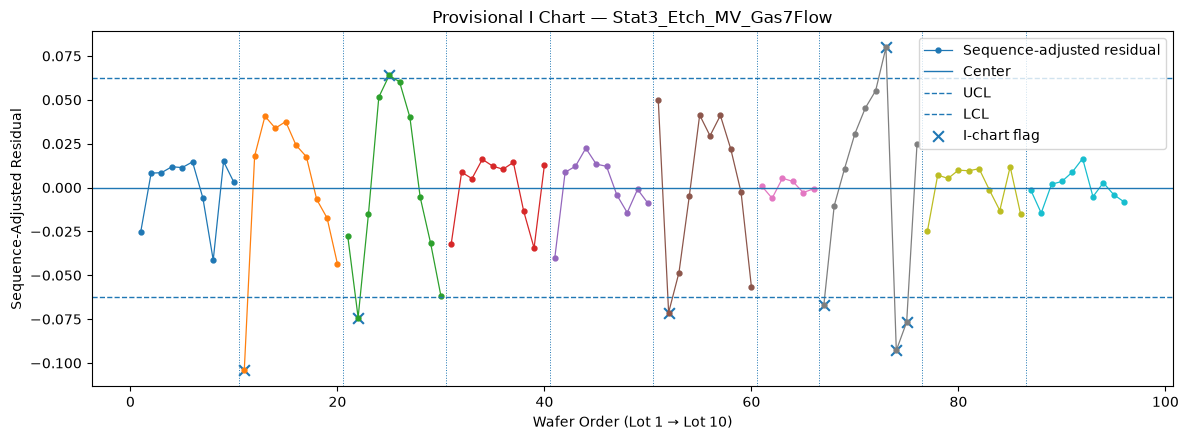

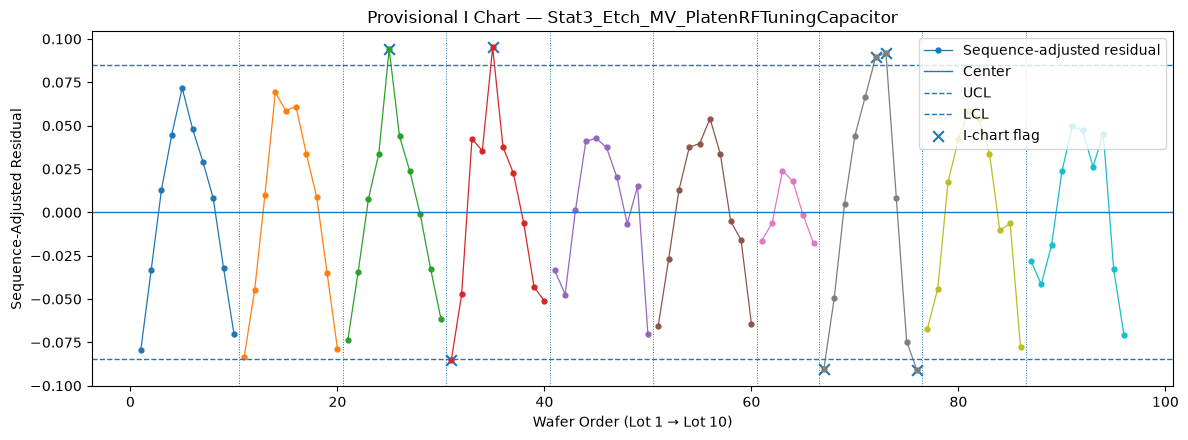

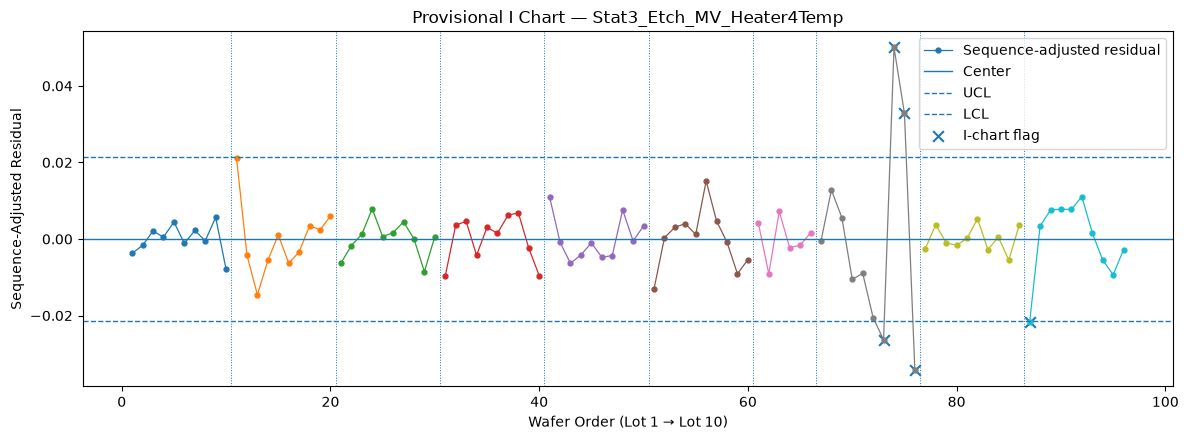

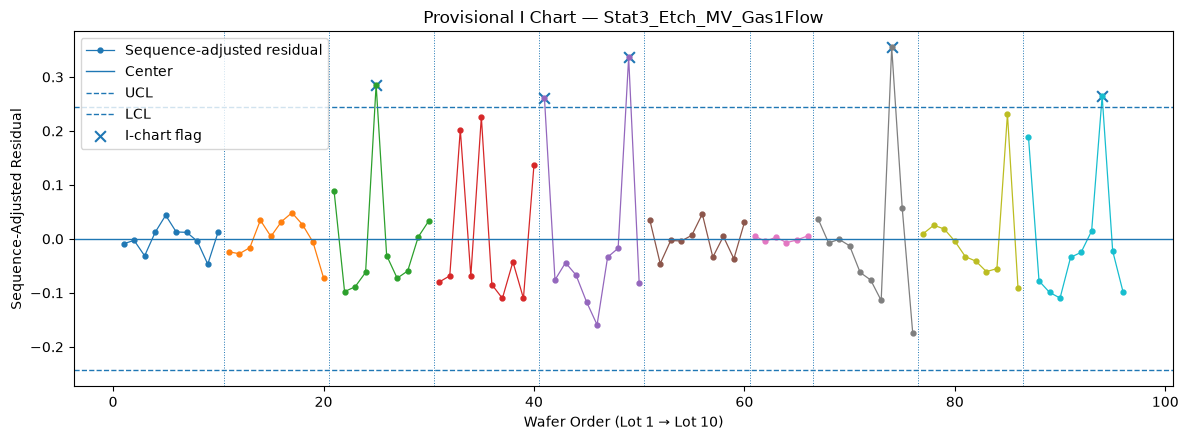

In [6]:
top_spc_features = (
    spc_feature_summary.loc[
        spc_feature_summary[
            "n_i_violations"
        ] > 0
    ]
    .copy()
)

display(
    top_spc_features[
        [
            "feature",
            "valid_lots",
            "n_valid_wafers",
            "n_i_violations",
            "i_violation_rate_pct",
            "max_abs_z",
            "n_valid_mr_pairs",
            "n_mr_violations",
            "mr_violation_rate_pct",
        ]
    ].head(15)
)


def plot_residual_i_chart(feature):
    feature_df = (
        spc_residuals.loc[
            (
                spc_residuals["feature"] == feature
            )
            &
            (
                spc_residuals["valid_lot"]
            )
        ]
        .sort_values(
            ["lot_number", "wafer_number"]
        )
        .reset_index(drop=True)
        .copy()
    )

    limits = limit_lookup.loc[feature]

    if len(feature_df) == 0:
        print(f"{feature}: no valid data")
        return

    feature_df["plot_order"] = np.arange(
        1,
        len(feature_df) + 1,
    )

    flagged = feature_df.loc[
        (
            feature_df["residual"]
            > limits["ucl"]
        )
        |
        (
            feature_df["residual"]
            < limits["lcl"]
        )
    ]

    fig, ax = plt.subplots(
        figsize=(12, 4.5)
    )

    first_lot = True

    for _, lot_df in (
        feature_df.groupby(
            "lot_number",
            sort=True,
        )
    ):
        ax.plot(
            lot_df["plot_order"],
            lot_df["residual"],
            marker="o",
            linewidth=0.9,
            markersize=3.5,
            label=(
                "Sequence-adjusted residual"
                if first_lot
                else None
            ),
        )
        first_lot = False

    ax.axhline(
        limits["center"],
        linewidth=1.0,
        label="Center",
    )
    ax.axhline(
        limits["ucl"],
        linestyle="--",
        linewidth=1.0,
        label="UCL",
    )
    ax.axhline(
        limits["lcl"],
        linestyle="--",
        linewidth=1.0,
        label="LCL",
    )

    if len(flagged) > 0:
        ax.scatter(
            flagged["plot_order"],
            flagged["residual"],
            marker="x",
            s=60,
            label="I-chart flag",
        )

    lot_change_positions = (
        feature_df["lot_number"]
        .ne(
            feature_df[
                "lot_number"
            ].shift()
        )
    )

    boundary_indices = (
        feature_df
        .index[lot_change_positions]
        .tolist()[1:]
    )

    for index in boundary_indices:
        ax.axvline(
            index + 0.5,
            linestyle=":",
            linewidth=0.7,
        )

    ax.set_xlabel(
        "Wafer Order (Lot 1 → Lot 10)"
    )
    ax.set_ylabel(
        "Sequence-Adjusted Residual"
    )
    ax.set_title(
        f"Provisional I Chart — {feature}"
    )
    ax.legend()

    plt.tight_layout()
    plt.show()


for feature in (
    top_spc_features[
        "feature"
    ]
    .head(4)
):
    plot_residual_i_chart(feature)

### 這幾張 I Chart 實際告訴我們什麼？

幾個代表性 features 的形狀不太一樣：

- `PlatenRFTuningCapacitor` 有多個 I flags，但 MR summary 裡沒有 MR violation，較像某些 wafer 的 **level deviation**，不是常常突然跳動。
- `Gas1Flow` 同時有 I flags 和很多 MR flags，表示不只 level 會偏離，相鄰 wafer 的 change 也比較明顯。
- `Heater4Temp` 的最大 residual 很大，但 MR flags 沒有同樣多，代表極端 level deviation 比較集中在少數 wafers。
- 幾張圖在 **Lot 8** 的區段都出現比較明顯的偏離。

因此這些圖真正幫助我的，是分辨 flag 比較像：

- isolated point
- step change
- 某個 Lot 共同出現的 structure
- 或是 linear model 在某個 Lot 沒有描述好

所以圖上的 flag 不等於「這片 wafer 壞掉」。Lot 8 多個 features 一起偏離的現象，應該留給後面的 multivariate analysis 再看是不是同一個共同 process state。


# Part C｜Moving Range Monitoring

## 7. 看相鄰 Wafer 的 Residual Change

MR 看的是：

> 從前一片 wafer 到目前這片 wafer，residual 的改變有沒有突然變大？

所以 MR 是 **pair-level signal**。

它和 I Chart 不一樣：I Chart 看一片 wafer 自己的位置，MR 看兩片相鄰 wafer 之間的變化。

這裡先按照 `n_mr_violations` 排序。


In [7]:
mr_summary = (
    spc_feature_summary[
        [
            "feature",
            "n_valid_mr_pairs",
            "n_mr_violations",
            "mr_violation_rate_pct",
            "mr_bar",
            "mr_ucl",
        ]
    ]
    .sort_values(
        [
            "n_mr_violations",
            "mr_violation_rate_pct",
        ],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)

display(
    mr_summary.head(15)
)

,feature,n_valid_mr_pairs,n_mr_violations,mr_violation_rate_pct,mr_bar,mr_ucl
0,Stat3_Etch_MV_Gas1Flow,86,8,9.302326,0.091604,0.299271
1,Stat3_Etch_MV_PlatenRFLoadCapacitor,86,7,8.139535,0.316896,1.035298
2,Stat3_Etch_MV_SourceRFLoadPower,86,5,5.813953,0.187733,0.613323
3,Stat3_Etch_MV_SourceRF2TuningCapacitor,54,4,7.407407,0.000616,0.002012
4,Stat3_Etch_MV_Gas7Flow,86,4,4.651163,0.023421,0.076516
5,Stat3_Etch_MV_ForeLinePressure,86,3,3.488372,0.113536,0.370922
6,Stat3_Etch_MV_HeliumBPPressure,86,3,3.488372,0.000094,0.000307
7,Stat3_Etch_MV_PlatenRFReflectedPower,86,3,3.488372,0.113848,0.371941
8,Stat3_Etch_MV_Heater4Temp,86,2,2.325581,0.008071,0.026368
9,Stat3_Etch_MV_Heater2Temp,86,2,2.325581,0.010629,0.034726


### 這個結果實際告訴我們什麼？

MR summary 的排序和 I summary 不一樣，正好說明兩種 chart 在看不同事情。

目前比較明顯的是：

- `Gas1Flow`：**8 個 MR flags**  
  代表它的 sequence-adjusted residual 在相鄰 wafers 之間多次出現比較大的跳動。

- `PlatenRFLoadCapacitor`：**7 個 MR flags**，但 I flags 很少  
  這個 signal 比較像對 transition 敏感，而不是很多 wafer 本身都落在極端 residual level。

- `SourceRFLoadPower`：**5 個 MR flags**  
  雖然單片 residual 不一定常超出 I limit，但相鄰 wafer 之間仍出現數次較大的 step change。

- `SourceRF2TuningCapacitor`：**4 個 MR flags**，但只有 **54 個 valid pairs**  
  所以它約 7.4% 的 MR violation rate 要和較少的有效 pairs 一起解讀。

因此 MR flag 比較正確的意思是：

> **「從前一片進到這一片時，Process residual 發生了一個值得回看的變化。」**

它不能單獨證明目前這片 wafer 本身就是異常來源。


## 8. 畫兩個代表性的 MR Charts

這裡挑：

- `Gas1Flow`
- `PlatenRFLoadCapacitor`

來看 MR chart。

Moving Range 仍然只在同一個 Lot 內計算，所以 Lot 邊界不會被當成相鄰 wafer transition。


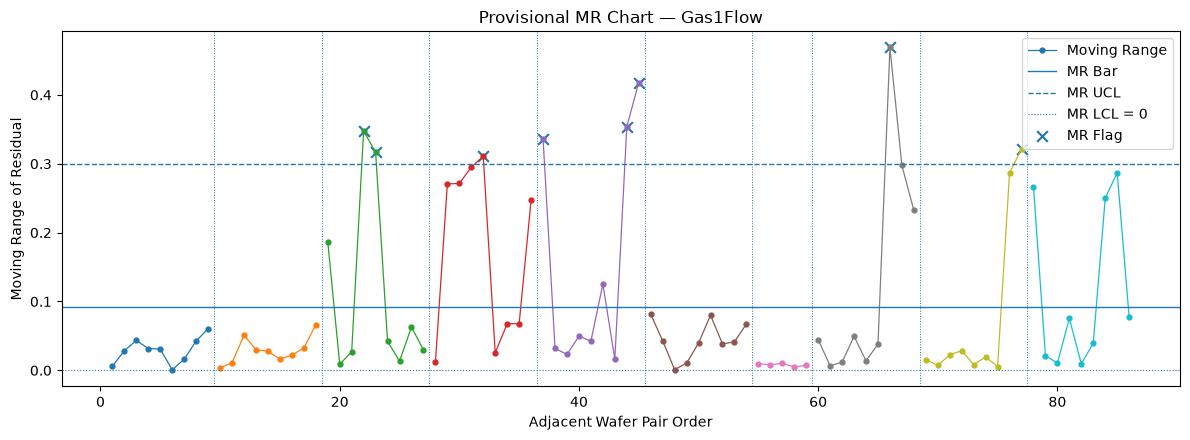

Feature： Stat3_Etch_MV_Gas1Flow
Valid MR Pairs： 86
MR Bar： 0.091604
MR UCL： 0.299271
MR Flags： 8
MR Flag Rate： 9.3 %


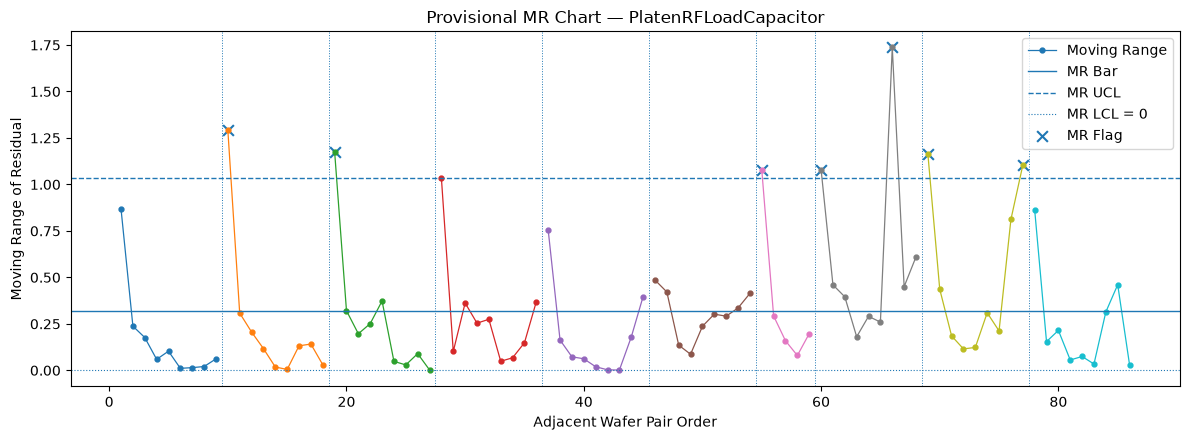

Feature： Stat3_Etch_MV_PlatenRFLoadCapacitor
Valid MR Pairs： 86
MR Bar： 0.316896
MR UCL： 1.035298
MR Flags： 7
MR Flag Rate： 8.14 %


In [8]:
def resolve_feature_name(feature_name):
    available_features = (
        spc_feature_summary[
            "feature"
        ]
        .astype(str)
        .tolist()
    )

    if feature_name in available_features:
        return feature_name

    matched_features = [
        feature
        for feature in available_features
        if feature.endswith(feature_name)
    ]

    if len(matched_features) == 1:
        return matched_features[0]

    if len(matched_features) == 0:
        raise ValueError(
            f"找不到 Feature：{feature_name}"
        )

    raise ValueError(
        f"Feature 名稱不唯一：{feature_name}\n"
        f"Matches：{matched_features}"
    )


def plot_mr_chart(feature_name):
    full_feature_name = resolve_feature_name(
        feature_name
    )

    feature_mr = (
        spc_moving_ranges.loc[
            spc_moving_ranges[
                "feature"
            ] == full_feature_name
        ]
        .sort_values(
            [
                "lot_number",
                "wafer_number",
            ]
        )
        .reset_index(drop=True)
        .copy()
    )

    limits = (
        spc_feature_summary
        .set_index("feature")
        .loc[full_feature_name]
    )

    if (
        len(feature_mr) == 0
        or not np.isfinite(
            limits["mr_ucl"]
        )
    ):
        print(
            f"{feature_name}: "
            "沒有有效 MR Chart 資料"
        )
        return

    feature_mr["plot_order"] = np.arange(
        1,
        len(feature_mr) + 1,
    )

    flagged = feature_mr.loc[
        feature_mr[
            "moving_range"
        ] > limits["mr_ucl"]
    ]

    fig, ax = plt.subplots(
        figsize=(12, 4.5)
    )

    first_lot = True

    for _, lot_df in (
        feature_mr
        .groupby(
            "lot_number",
            sort=True,
        )
    ):
        ax.plot(
            lot_df["plot_order"],
            lot_df["moving_range"],
            marker="o",
            linewidth=0.9,
            markersize=3.5,
            label=(
                "Moving Range"
                if first_lot
                else None
            ),
        )
        first_lot = False

    ax.axhline(
        limits["mr_bar"],
        linewidth=1.0,
        label="MR Bar",
    )
    ax.axhline(
        limits["mr_ucl"],
        linestyle="--",
        linewidth=1.0,
        label="MR UCL",
    )
    ax.axhline(
        0,
        linestyle=":",
        linewidth=0.8,
        label="MR LCL = 0",
    )

    if len(flagged) > 0:
        ax.scatter(
            flagged["plot_order"],
            flagged["moving_range"],
            marker="x",
            s=60,
            label="MR Flag",
        )

    lot_change_positions = (
        feature_mr["lot_number"]
        .ne(
            feature_mr[
                "lot_number"
            ].shift()
        )
    )

    boundary_indices = (
        feature_mr
        .index[lot_change_positions]
        .tolist()[1:]
    )

    for index in boundary_indices:
        ax.axvline(
            index + 0.5,
            linestyle=":",
            linewidth=0.7,
        )

    ax.set_xlabel(
        "Adjacent Wafer Pair Order"
    )
    ax.set_ylabel(
        "Moving Range of Residual"
    )
    ax.set_title(
        "Provisional MR Chart — "
        f"{feature_name}"
    )
    ax.legend()

    plt.tight_layout()
    plt.show()

    print(
        "Feature：",
        full_feature_name,
    )
    print(
        "Valid MR Pairs：",
        int(
            limits["n_valid_mr_pairs"]
        ),
    )
    print(
        "MR Bar：",
        round(limits["mr_bar"], 6),
    )
    print(
        "MR UCL：",
        round(limits["mr_ucl"], 6),
    )
    print(
        "MR Flags：",
        int(
            limits["n_mr_violations"]
        ),
    )
    print(
        "MR Flag Rate：",
        round(
            limits[
                "mr_violation_rate_pct"
            ],
            2,
        ),
        "%",
    )


for feature in [
    "Gas1Flow",
    "PlatenRFLoadCapacitor",
]:
    plot_mr_chart(feature)

### 這兩張 MR Chart 實際告訴我們什麼？

兩個 features 的 scale 不一樣：

- `Gas1Flow`：MR UCL ≈ **0.299**，MR Flags = **8**，Flag Rate ≈ **9.3%**
- `PlatenRFLoadCapacitor`：MR UCL ≈ **1.035**，MR Flags = **7**，Flag Rate ≈ **8.14%**

不能因為 1.035 比 0.299 大，就說 `PlatenRFLoadCapacitor`「允許更大的異常」。兩個 sensors 的單位和自然波動尺度不同，UCL 本來就不能直接跨 feature 比數值大小。

真正要看的是：

- 各自有沒有超過自己的 MR UCL
- 超過幾次
- 超限是不是集中在特定 Lot 或 wafer transition

因此這兩張圖提供的是不同 feature 的 **transition evidence**，不是 raw MR magnitude 的大小排名。


# Part D｜Main Active Duration Secondary Check

## 9. 額外檢查 Main Active Duration 的 I-MR

03 已經看到 96 片 wafer 的 Main Active Duration 非常集中。

所以 05 另外把 Duration 當成一個 secondary timing metric，做 retrospective I-MR screening。

Duration 這裡沒有另外做 sequence detrending，所以解讀會更保守。

MR 一樣只在同一個 Lot 內計算，不跨 Lot。這一段只是確認 processing time 有沒有明顯不穩定，不代表已經證明所有 Lots 共用完全相同的 baseline。


In [9]:
duration_df = (
    process_wafer_summary[
        [
            "experiment_key",
            "lot_number",
            "wafer_number",
            "main_active_duration",
        ]
    ]
    .sort_values(
        ["lot_number", "wafer_number"]
    )
    .reset_index(drop=True)
)

duration_mr_records = []

for lot_number, group in (
    duration_df.groupby("lot_number")
):
    group = group.sort_values(
        "wafer_number"
    )

    values = group[
        "main_active_duration"
    ].to_numpy(dtype=float)

    if len(values) < 2:
        continue

    moving_ranges = np.abs(
        np.diff(values)
    )

    previous_rows = group.iloc[:-1]
    current_rows = group.iloc[1:]

    for (
        previous_key,
        previous_wafer,
        current_key,
        current_wafer,
        mr_value,
    ) in zip(
        previous_rows["experiment_key"],
        previous_rows["wafer_number"],
        current_rows["experiment_key"],
        current_rows["wafer_number"],
        moving_ranges,
    ):
        duration_mr_records.append(
            {
                "lot_number": int(lot_number),
                "previous_experiment_key": previous_key,
                "previous_wafer_number": int(previous_wafer),
                "experiment_key": current_key,
                "wafer_number": int(current_wafer),
                "moving_range": float(mr_value),
            }
        )

duration_mr_df = pd.DataFrame(
    duration_mr_records
)

assert len(duration_mr_df) == 86

duration_center = float(
    duration_df[
        "main_active_duration"
    ].mean()
)

duration_mr_bar = float(
    duration_mr_df[
        "moving_range"
    ].mean()
)

duration_sigma = (
    duration_mr_bar / D2
)

duration_lcl = (
    duration_center
    - 3 * duration_sigma
)

duration_ucl = (
    duration_center
    + 3 * duration_sigma
)

duration_mr_ucl = (
    D4 * duration_mr_bar
)

duration_flags = (
    duration_df.loc[
        (
            duration_df[
                "main_active_duration"
            ] < duration_lcl
        )
        |
        (
            duration_df[
                "main_active_duration"
            ] > duration_ucl
        )
    ]
    .copy()
)

duration_mr_flags = (
    duration_mr_df.loc[
        duration_mr_df[
            "moving_range"
        ] > duration_mr_ucl
    ]
    .copy()
)

print(
    "Duration Center：",
    round(duration_center, 3),
)
print(
    "Estimated Sigma：",
    round(duration_sigma, 3),
)
print(
    "I-chart LCL：",
    round(duration_lcl, 3),
)
print(
    "I-chart UCL：",
    round(duration_ucl, 3),
)
print(
    "Duration I Flags：",
    len(duration_flags),
)
print(
    "Duration MR Bar：",
    round(duration_mr_bar, 3),
)
print(
    "Duration MR UCL：",
    round(duration_mr_ucl, 3),
)
print(
    "Duration MR Flags：",
    len(duration_mr_flags),
)

display(duration_flags)

Duration Center： 597.542
Estimated Sigma： 1.876
I-chart LCL： 591.913
I-chart UCL： 603.171
Duration I Flags： 2
Duration MR Bar： 2.116
Duration MR UCL： 6.914
Duration MR Flags： 4


,experiment_key,lot_number,wafer_number,main_active_duration
29,2024-07-09_10,3,10,591.8
41,2024-07-19_02,5,2,591.8


### 這個結果實際告訴我們什麼？

Main Active Duration 的結果是：

- Center ≈ **597.542 秒**
- Estimated Sigma ≈ **1.876 秒**
- I-chart LCL ≈ **591.913 秒**
- I-chart UCL ≈ **603.171 秒**
- Duration I Flags = **2**
- MR Bar ≈ **2.116 秒**
- MR UCL ≈ **6.914 秒**
- Duration MR Flags = **4**

兩片 I flag wafers 都是 **591.8 秒**：

- `2024-07-09_10`
- `2024-07-19_02`

但 591.8 秒只比 LCL 591.913 秒低大約 **0.11 秒**。

而 03 已確認 nominal sampling interval 約 **0.2 秒**，也就是說這個超限幅度甚至小於一個 nominal sampling interval。

所以這兩個 Duration I flags 很接近邊界，也很容易受到 sampling discretization 或 boundary detection 影響，不能拿來說有明顯 processing-time failure。

另外有 **4 個 MR flags**，代表某些相鄰 wafers 的 active duration change 比目前一般 transition scale 大。這和「單片 duration level 太低」是不同 evidence。


## 10. 畫 Duration I Chart 和 MR Chart

I Chart 會依 Lot 分段畫，不跨 Lot 連線。

MR Chart 也只計算同一 Lot 裡的 adjacent wafer pairs。

這樣可以把「單片 duration level」和「相鄰 wafer duration change」分開看。


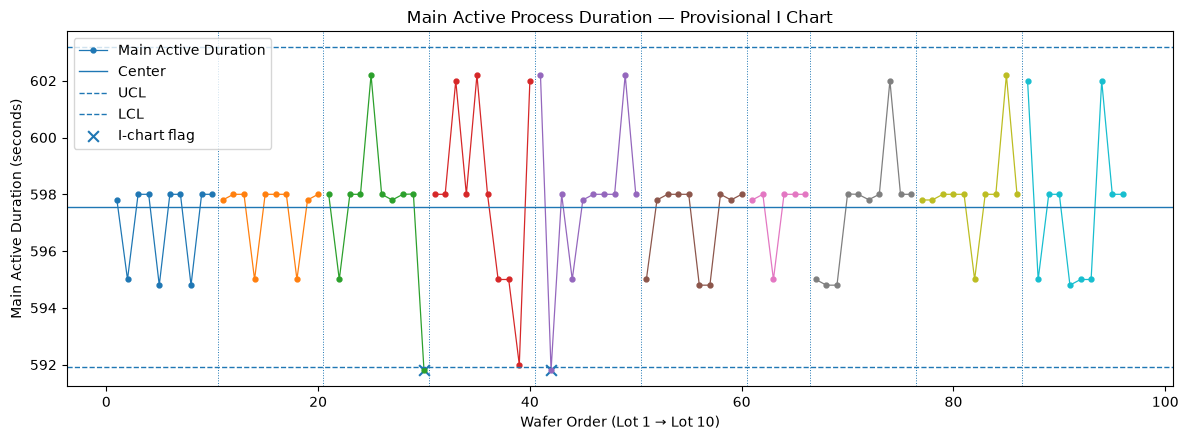

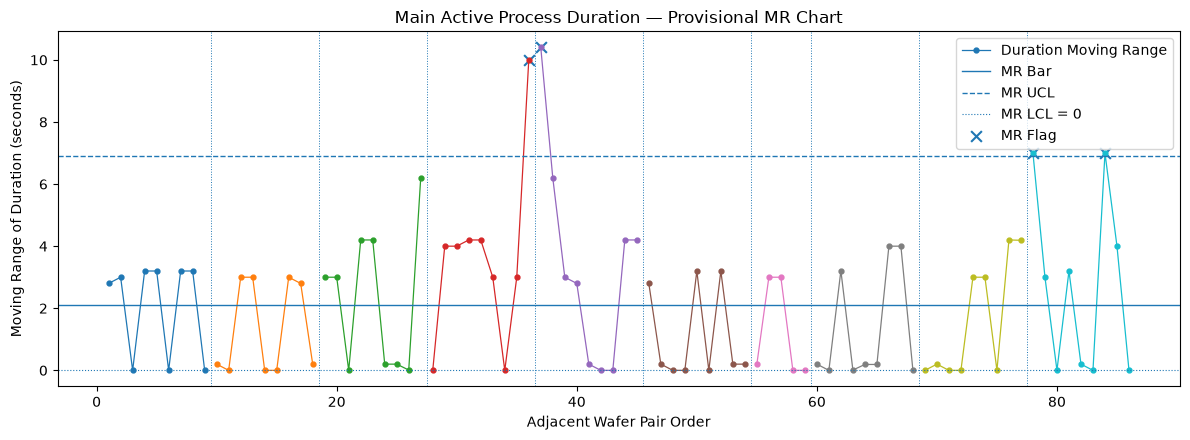

In [10]:
duration_plot = duration_df.copy()
duration_plot["plot_order"] = np.arange(
    1,
    len(duration_plot) + 1,
)

fig, ax = plt.subplots(
    figsize=(12, 4.5)
)

first_lot = True

for _, lot_df in (
    duration_plot
    .groupby(
        "lot_number",
        sort=True,
    )
):
    ax.plot(
        lot_df["plot_order"],
        lot_df["main_active_duration"],
        marker="o",
        linewidth=0.9,
        markersize=3.5,
        label=(
            "Main Active Duration"
            if first_lot
            else None
        ),
    )
    first_lot = False

ax.axhline(
    duration_center,
    linewidth=1.0,
    label="Center",
)
ax.axhline(
    duration_ucl,
    linestyle="--",
    linewidth=1.0,
    label="UCL",
)
ax.axhline(
    duration_lcl,
    linestyle="--",
    linewidth=1.0,
    label="LCL",
)

if len(duration_flags) > 0:
    flagged_mask = (
        duration_plot[
            "experiment_key"
        ]
        .isin(
            duration_flags[
                "experiment_key"
            ]
        )
    )

    ax.scatter(
        duration_plot.loc[
            flagged_mask,
            "plot_order",
        ],
        duration_plot.loc[
            flagged_mask,
            "main_active_duration",
        ],
        marker="x",
        s=60,
        label="I-chart flag",
    )

lot_change_positions = (
    duration_plot["lot_number"]
    .ne(
        duration_plot[
            "lot_number"
        ].shift()
    )
)

for index in (
    duration_plot
    .index[lot_change_positions]
    .tolist()[1:]
):
    ax.axvline(
        index + 0.5,
        linestyle=":",
        linewidth=0.7,
    )

ax.set_xlabel(
    "Wafer Order (Lot 1 → Lot 10)"
)
ax.set_ylabel(
    "Main Active Duration (seconds)"
)
ax.set_title(
    "Main Active Process Duration — Provisional I Chart"
)
ax.legend()

plt.tight_layout()
plt.show()


duration_mr_plot = (
    duration_mr_df
    .sort_values(
        ["lot_number", "wafer_number"]
    )
    .reset_index(drop=True)
    .copy()
)

duration_mr_plot["plot_order"] = np.arange(
    1,
    len(duration_mr_plot) + 1,
)

fig, ax = plt.subplots(
    figsize=(12, 4.5)
)

first_lot = True

for _, lot_df in (
    duration_mr_plot
    .groupby(
        "lot_number",
        sort=True,
    )
):
    ax.plot(
        lot_df["plot_order"],
        lot_df["moving_range"],
        marker="o",
        linewidth=0.9,
        markersize=3.5,
        label=(
            "Duration Moving Range"
            if first_lot
            else None
        ),
    )
    first_lot = False

ax.axhline(
    duration_mr_bar,
    linewidth=1.0,
    label="MR Bar",
)
ax.axhline(
    duration_mr_ucl,
    linestyle="--",
    linewidth=1.0,
    label="MR UCL",
)
ax.axhline(
    0,
    linestyle=":",
    linewidth=0.8,
    label="MR LCL = 0",
)

flagged_duration_mr = (
    duration_mr_plot.loc[
        duration_mr_plot[
            "moving_range"
        ] > duration_mr_ucl
    ]
)

if len(flagged_duration_mr) > 0:
    ax.scatter(
        flagged_duration_mr["plot_order"],
        flagged_duration_mr["moving_range"],
        marker="x",
        s=60,
        label="MR Flag",
    )

lot_change_positions = (
    duration_mr_plot["lot_number"]
    .ne(
        duration_mr_plot[
            "lot_number"
        ].shift()
    )
)

for index in (
    duration_mr_plot
    .index[lot_change_positions]
    .tolist()[1:]
):
    ax.axvline(
        index + 0.5,
        linestyle=":",
        linewidth=0.7,
    )

ax.set_xlabel(
    "Adjacent Wafer Pair Order"
)
ax.set_ylabel(
    "Moving Range of Duration (seconds)"
)
ax.set_title(
    "Main Active Process Duration — Provisional MR Chart"
)
ax.legend()

plt.tight_layout()
plt.show()

### 這兩張 Duration Chart 實際告訴我們什麼？

I Chart 只有 **2 片 wafer** 落在 LCL 外，而且兩片都只超過邊界大約 0.11 秒。

所以從 level 來看，Main Active Duration 整體仍然非常穩定，沒有看到大幅偏離。

但 MR Chart 有 **4 個 within-lot jumps**。

這表示即使兩片 wafer 各自的 duration 都還在一般 level 範圍內，前一片到下一片的差值仍然可能比平常大。

因此兩張圖要分開解讀：

- I Chart：看「這片 wafer 的 duration level」
- MR Chart：看「前一片到這一片的 duration change」

兩種 flags 代表不同問題，不能直接相加成一個「Duration 異常次數」。


# Part E｜Wafer-Level Evidence Summary

## 11. 把 I-Level 和 MR Transition Evidence 放到同一張 Wafer Table

前面 I flag 和 MR flag 的單位不同，所以這裡不是要硬做一個 risk score，而是把兩種 evidence 放在同一張 wafer-level table，方便後面查。

### I Flag
記在目前這片 wafer，代表某個 feature 的 residual level 超過 provisional I limits。

### MR Flag
本質上是 previous wafer → current wafer 的 pair-level signal。

為了可以和 wafer table 合併，我把 MR flag 記在 jump 後面的 **current wafer**，但 detail table 仍保留：

- previous experiment key
- previous wafer number
- current experiment key
- current wafer number

所以 MR flag 的正確意思是：

> 「進入這片 wafer 時，某個 Process residual 發生比較大的 step change。」

它不能單獨證明 current wafer 本身就是問題來源。

表格目前用 I-level evidence 數量排序只是為了比較好閱讀，不是正式 severity ranking。


In [11]:
mr_limit_lookup = (
    spc_feature_summary
    .set_index("feature")["mr_ucl"]
)

spc_moving_ranges = (
    spc_moving_ranges
    .copy()
)

spc_moving_ranges["mr_ucl"] = (
    spc_moving_ranges[
        "feature"
    ].map(mr_limit_lookup)
)

spc_moving_ranges["is_mr_violation"] = (
    spc_moving_ranges[
        "moving_range"
    ]
    >
    spc_moving_ranges[
        "mr_ucl"
    ]
)

spc_moving_ranges["mr_ratio_to_ucl"] = (
    spc_moving_ranges[
        "moving_range"
    ]
    /
    spc_moving_ranges[
        "mr_ucl"
    ]
)

spc_mr_flags = (
    spc_moving_ranges.loc[
        spc_moving_ranges[
            "is_mr_violation"
        ]
    ]
    .copy()
)

expected_mr_flag_rows = int(
    spc_feature_summary["n_mr_violations"].sum()
)

actual_mr_flag_rows = len(spc_mr_flags)

print(
    "Feature Summary 推導的 MR Flag Rows：",
    expected_mr_flag_rows,
)
print(
    "MR Detail 實際 MR Flag Rows：",
    actual_mr_flag_rows,
)

assert actual_mr_flag_rows == expected_mr_flag_rows, (
    "MR summary 與 MR detail 不一致："
    f"summary={expected_mr_flag_rows}, "
    f"detail={actual_mr_flag_rows}"
)

i_flag_summary = (
    spc_flagged_wafers
    .groupby("experiment_key")
    .agg(
        n_flagged_features=(
            "feature",
            "nunique",
        ),
        max_abs_standardized_residual=(
            "standardized_residual",
            lambda s:
                float(
                    np.max(
                        np.abs(s)
                    )
                ),
        ),
        flagged_features=(
            "feature",
            lambda s:
                " | ".join(
                    sorted(set(s))
                ),
        ),
    )
    .reset_index()
)

mr_flag_summary = (
    spc_mr_flags
    .groupby("experiment_key")
    .agg(
        n_mr_flagged_features=(
            "feature",
            "nunique",
        ),
        max_mr_ratio_to_ucl=(
            "mr_ratio_to_ucl",
            "max",
        ),
        mr_flagged_features=(
            "feature",
            lambda s:
                " | ".join(
                    sorted(set(s))
                ),
        ),
    )
    .reset_index()
)

flagged_keys = pd.DataFrame(
    {
        "experiment_key": sorted(
            set(
                i_flag_summary[
                    "experiment_key"
                ]
            )
            |
            set(
                mr_flag_summary[
                    "experiment_key"
                ]
            )
        )
    }
)

wafer_metadata = (
    process_wafer_summary[
        [
            "experiment_key",
            "lot_number",
            "wafer_number",
        ]
    ]
    .drop_duplicates(
        subset=["experiment_key"]
    )
)

wafer_flag_summary = (
    flagged_keys
    .merge(
        wafer_metadata,
        on="experiment_key",
        how="left",
        validate="one_to_one",
    )
    .merge(
        i_flag_summary,
        on="experiment_key",
        how="left",
        validate="one_to_one",
    )
    .merge(
        mr_flag_summary,
        on="experiment_key",
        how="left",
        validate="one_to_one",
    )
)

wafer_flag_summary[
    "n_flagged_features"
] = (
    wafer_flag_summary[
        "n_flagged_features"
    ]
    .fillna(0)
    .astype(int)
)

wafer_flag_summary[
    "n_mr_flagged_features"
] = (
    wafer_flag_summary[
        "n_mr_flagged_features"
    ]
    .fillna(0)
    .astype(int)
)

wafer_flag_summary["flagged_features"] = (
    wafer_flag_summary[
        "flagged_features"
    ]
    .fillna("")
)

wafer_flag_summary[
    "mr_flagged_features"
] = (
    wafer_flag_summary[
        "mr_flagged_features"
    ]
    .fillna("")
)

wafer_flag_summary["has_mr_jump"] = (
    wafer_flag_summary[
        "n_mr_flagged_features"
    ] > 0
)

wafer_flag_summary = (
    wafer_flag_summary
    .sort_values(
        [
            "n_flagged_features",
            "max_abs_standardized_residual",
            "n_mr_flagged_features",
        ],
        ascending=[False, False, False],
        na_position="last",
    )
    .reset_index(drop=True)
)

print(
    "MR Flag Rows：",
    len(spc_mr_flags),
)

display(
    wafer_flag_summary[
        [
            "experiment_key",
            "lot_number",
            "wafer_number",
            "n_flagged_features",
            "max_abs_standardized_residual",
            "n_mr_flagged_features",
            "max_mr_ratio_to_ucl",
            "has_mr_jump",
            "flagged_features",
            "mr_flagged_features",
        ]
    ]
    .head(20)
)

Feature Summary 推導的 MR Flag Rows： 47
MR Detail 實際 MR Flag Rows： 47
MR Flag Rows： 47


,experiment_key,lot_number,wafer_number,n_flagged_features,max_abs_standardized_residual,n_mr_flagged_features,max_mr_ratio_to_ucl,has_mr_jump,flagged_features,mr_flagged_features
0,2024-08-07_08,8,8,5,6.993740,5,2.896139,True,Stat3_Etch_MV_Gas1Flow | Stat3_Etch_MV_Gas2Flo...,Stat3_Etch_MV_Gas1Flow | Stat3_Etch_MV_Gas2Flo...
1,2024-07-09_05,3,5,5,3.517924,1,1.161884,True,Stat3_Etch_MV_Gas1Flow | Stat3_Etch_MV_Gas7Flo...,Stat3_Etch_MV_Gas1Flow
2,2024-08-07_09,8,9,4,4.852115,1,1.210185,True,Stat3_Etch_MV_Gas2Flow | Stat3_Etch_MV_Gas7Flo...,Stat3_Etch_MV_Heater2Temp
3,2024-08-07_07,8,7,4,3.845601,0,NaN,False,Stat3_Etch_MV_Gas7Flow | Stat3_Etch_MV_Heater4...,
4,2024-08-07_01,8,1,4,3.557716,0,NaN,False,Stat3_Etch_MV_ForeLinePressure | Stat3_Etch_MV...,
5,2024-07-05_01,2,1,3,5.018226,0,NaN,False,Stat3_Etch_MV_Gas7Flow | Stat3_Etch_MV_Heater2...,
6,2024-08-07_10,8,10,3,4.795336,5,2.546458,True,Stat3_Etch_MV_Heater4Temp | Stat3_Etch_MV_Heli...,Stat3_Etch_MV_Gas2Flow | Stat3_Etch_MV_Gas7Flo...
7,2024-08-22_08,10,8,3,3.289013,1,1.005244,True,Stat3_Etch_MV_Gas1Flow | Stat3_Etch_MV_SourceR...,Stat3_Etch_MV_SourceRF2TuningCapacitor
8,2024-08-07_06,8,6,2,4.743020,0,NaN,False,Stat3_Etch_MV_Heater2Temp | Stat3_Etch_MV_Plat...,
9,2024-07-19_09,5,9,2,4.140354,2,1.181839,True,Stat3_Etch_MV_Gas1Flow | Stat3_Etch_MV_SourceR...,Stat3_Etch_MV_Gas1Flow | Stat3_Etch_MV_SourceR...


### 這個結果實際告訴我們什麼？

先看資料一致性：

- 從 Feature-level summary 推回來的 MR flags = **47**
- MR detail table 實際的 MR flag rows = **47**

兩邊完全一致，所以這次正確的 MR flag 數就是 **47**，summary 和 detail 沒有對不上。

再看 wafer-level pattern，可以看到不同類型：

- `2024-08-07_08`：**5 個 I-feature flags + 5 個 MR-feature flags**  
  代表 residual level 和進入這片 wafer 前的 transition evidence 都很強。

- `2024-08-07_10`：**3 個 I flags + 5 個 MR flags**  
  同樣同時有兩種 evidence。

- `2024-07-09_05`：**5 個 I flags + 1 個 MR flag**  
  比較偏向多個 features 的 level deviation，不是大量 abrupt transition。

- `2024-08-21_10`：**0 個 I flag + 4 個 MR flags**  
  這個例子很清楚地說明：相鄰 wafer 的 transition unusual，不代表目前這片 wafer 的 residual level 一定 extreme。

另外，表格前面的 evidence-rich wafers 有不少來自 **Lot 8**。

所以這張 summary 最有用的地方，是幫後面 06 找出一個更值得追的問題：

> **Lot 8 多個 features 同時被 flag，是不是其實反映同一個 multivariate / lot-level process state？**

目前還不能直接把這些 flags 當成正式 risk score。


# Part F｜輸出 05 的 SPC Artifacts

## 12. 寫出結果並重新讀回檢查

05 會輸出 9 份 SPC artifacts：

- `spc_sequence_adjusted_residuals.csv`
- `spc_feature_summary.csv`
- `spc_flagged_feature_wafers.csv`
- `spc_wafer_flag_summary.csv`
- `spc_moving_ranges.csv`
- `spc_mr_flags.csv`
- `spc_duration_flags.csv`
- `spc_duration_moving_ranges.csv`
- `spc_duration_mr_flags.csv`

這裡不另外再存一份 `process_wafer_summary_spc.csv`。

Process wafer summary 仍然由 03 的 `process_wafer_summary.csv` 負責，避免同一份上游資料有多個版本。


In [12]:
output_tables = {
    "spc_sequence_adjusted_residuals.csv": spc_residuals,
    "spc_feature_summary.csv": spc_feature_summary,
    "spc_flagged_feature_wafers.csv": spc_flagged_wafers,
    "spc_wafer_flag_summary.csv": wafer_flag_summary,
    "spc_moving_ranges.csv": spc_moving_ranges,
    "spc_mr_flags.csv": spc_mr_flags,
    "spc_duration_flags.csv": duration_flags,
    "spc_duration_moving_ranges.csv": duration_mr_df,
    "spc_duration_mr_flags.csv": duration_mr_flags,
}

for filename, dataframe in output_tables.items():
    dataframe.to_csv(
        PROCESSED_DATA_DIR / filename,
        index=False,
    )

output_checks = []

for filename, dataframe in output_tables.items():
    path = PROCESSED_DATA_DIR / filename
    reloaded = pd.read_csv(path)

    output_checks.append(
        {
            "file": filename,
            "exists": path.exists(),
            "rows_match": len(reloaded) == len(dataframe),
            "columns_match": (
                list(reloaded.columns)
                == list(dataframe.columns)
            ),
        }
    )

output_checks_df = pd.DataFrame(
    output_checks
)

assert output_checks_df[
    ["exists", "rows_match", "columns_match"]
].all().all()

assert len(
    pd.read_csv(
        PROCESSED_DATA_DIR
        / "spc_sequence_adjusted_residuals.csv"
    )
) == 2592

assert len(
    pd.read_csv(
        PROCESSED_DATA_DIR
        / "spc_feature_summary.csv"
    )
) == 27

assert len(
    pd.read_csv(
        PROCESSED_DATA_DIR
        / "spc_flagged_feature_wafers.csv"
    )
) == 46

assert len(
    pd.read_csv(
        PROCESSED_DATA_DIR
        / "spc_moving_ranges.csv"
    )
) == 2118

reloaded_mr_flags = pd.read_csv(
    PROCESSED_DATA_DIR
    / "spc_mr_flags.csv"
)

assert len(reloaded_mr_flags) == len(spc_mr_flags)
assert len(reloaded_mr_flags) == expected_mr_flag_rows

assert len(
    pd.read_csv(
        PROCESSED_DATA_DIR
        / "spc_duration_flags.csv"
    )
) == 2

assert len(
    pd.read_csv(
        PROCESSED_DATA_DIR
        / "spc_duration_moving_ranges.csv"
    )
) == 86

assert len(
    pd.read_csv(
        PROCESSED_DATA_DIR
        / "spc_duration_mr_flags.csv"
    )
) == 4

output_checks_df

,file,exists,rows_match,columns_match
0,spc_sequence_adjusted_residuals.csv,True,True,True
1,spc_feature_summary.csv,True,True,True
2,spc_flagged_feature_wafers.csv,True,True,True
3,spc_wafer_flag_summary.csv,True,True,True
4,spc_moving_ranges.csv,True,True,True
5,spc_mr_flags.csv,True,True,True
6,spc_duration_flags.csv,True,True,True
7,spc_duration_moving_ranges.csv,True,True,True
8,spc_duration_mr_flags.csv,True,True,True


### 這個結果實際告訴我們什麼？

9 個 SPC artifacts 全部：

- 檔案存在
- rows 和記憶體結果一致
- columns 和記憶體結果一致

目前主要 row counts 是：

- Sequence-adjusted residual records = **2,592**
- Feature summaries = **27**
- I-flag detail rows = **46**
- MR pair records = **2,118**
- MR flag rows = **47**
- Duration I flags = **2**
- Duration MR pairs = **86**
- Duration MR flags = **4**

這些數字不是在說「品質好或不好」，而是在確認這份 Notebook 產生的 summary 和 detail tables 是同一個版本。

也就是說，06 或 10 後面再讀這些 CSV 時，不會因為寫檔漏 row、schema 改掉或混入舊 artifact，而看到和 05 當下不同的結果。


# 13. 05 整體結論

這份 05 的目的，是在已知 Process signals 具有 wafer-sequence structure 的情況下，建立一套比較合理的 **sequence-adjusted Phase-I retrospective screening**。

首先，我不是直接監控 raw process means，而是先在每個 Feature × Lot 裡扣掉 linear wafer-sequence trend，最後得到 **2,592 筆 residual records**。這樣做是因為 03 已經確認很多 process signals 會跟著 wafer number 系統性變化，如果直接畫 raw I-MR chart，很容易把正常 sequence trend 當成異常。

在 residual I Chart 中，一共得到：

- **46 個 Feature–Wafer I flags**
- 分布在 **19 片 unique wafers**

所以 I flags 有明顯聚集，不是均勻散在 96 片 wafer 上。

不同 features 的型態也不一樣：

- `PlatenRFTuningCapacitor`：I flags 多、MR flags = 0，偏向 **level deviation**
- `PlatenRFLoadCapacitor`：I flags 少、MR flags 多，偏向 **transition change**
- `Gas1Flow`：I 和 MR flags 都多，兩種 evidence 都存在

MR 這邊總共有 **47 個 flag rows**，而且 feature summary 推導出的數量和 detail table 完全一致。

Wafer-level summary 也看到一些 evidence 比較集中的案例：

- `2024-08-07_08`：5 個 I flags + 5 個 MR flags
- `2024-08-07_10`：3 個 I flags + 5 個 MR flags
- `2024-07-09_05`：5 個 I flags + 1 個 MR flag
- `2024-08-21_10`：0 個 I flag + 4 個 MR flags

其中不少 evidence-rich wafers 都出現在 **Lot 8**。這表示後面更值得檢查的是：這些單變量 flags 是否其實來自同一個 shared lot-level 或 multivariate process structure，而不是把每個 flag 都當成獨立故障。

Main Active Duration 的結果則相對穩定：

- Center ≈ **597.542 秒**
- I flags = **2**
- 兩片都是 **591.8 秒**
- 只比 LCL 約低 **0.11 秒**
- Duration MR flags = **4**

因為 0.11 秒甚至小於約 0.2 秒的 nominal sampling interval，所以這兩個 Duration I flags 很接近邊界，不支持「processing time 明顯失控」這種說法。

整體來說，05 最重要的結論不是單純數 flag，而是：

> **Process deviation 有不同型態：有些是單片 level 偏離，有些是相鄰 wafer transition 變大，有些則在同一個 Lot 裡同時出現在多個 signals。**

目前這些結果只能當作 retrospective screening evidence，還不能直接稱為：

- production OOC
- equipment failure
- quality defect
- causal process driver
- production-ready control limits

原因是 trend 和 limits 都用同一批 Phase-I data 估計，而且 linear detrending 可能漏掉 non-linear sequence；不同 Lots 的 residual variance 也還沒有證明完全一致。

因此下一步 06 比較合理的方向，是直接使用：

- 03 的 `process_wafer_summary.csv`
- 05 的 `spc_sequence_adjusted_residuals.csv`
- 05 的 `spc_feature_summary.csv`

繼續看目前這些單變量 flags 是否可以被較少數的 multivariate process directions 解釋，而不是再重新做 segmentation 或 residualization。
